# OpenCV Main Functions

In [ ]:
# Install OpenCV if not already installed
# Uncomment the following line if needed

# !pip install opencv-python


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## 1. Reading & Writing Images

In [3]:
# Reading an image
img = cv2.imread('sample.jpeg')

# Check if image is loaded
if img is None:
    print("Image not found. Please place 'sample.jpg' in the notebook directory.")
else:
    print("Image loaded successfully")

    # Writing image
    cv2.imwrite('output.jpg', img)
    print("Image saved as output.jpg")


Image loaded successfully
Image saved as output.jpg


## 2. Resizing & Cropping

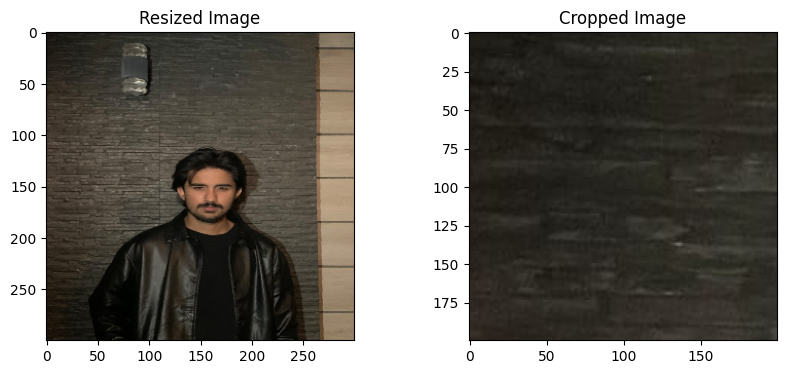

In [9]:
if img is not None:

    # Resize image
    resized = cv2.resize(img, (300, 300))

    # Crop image using array slicing
    cropped = img[50:250, 50:250]

    # Display using matplotlib
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    plt.title("Resized Image")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title("Cropped Image")

    plt.show()


## 3. Color Spaces

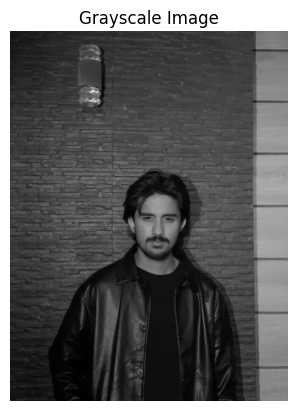

In [10]:
if img is not None:

    # Convert BGR to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')
    plt.show()


## 4. Drawing Shapes

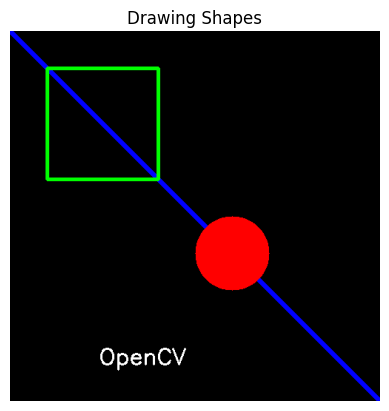

In [12]:
# Create blank image
canvas = np.zeros((500, 500, 3), dtype='uint8')

# Draw line
cv2.line(canvas, (0, 0), (500, 500), (255, 0, 0), 5)

# Draw rectangle
cv2.rectangle(canvas, (50, 50), (200, 200), (0, 255, 0), 3)

# Draw circle
cv2.circle(canvas, (300, 300), 50, (0, 0, 255), -1)

# Put text
cv2.putText(canvas, 'OpenCV', (120, 450),
            cv2.FONT_HERSHEY_SIMPLEX, 1,
            (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Drawing Shapes")
plt.axis('off')
plt.show()


## 5. Image Thresholding

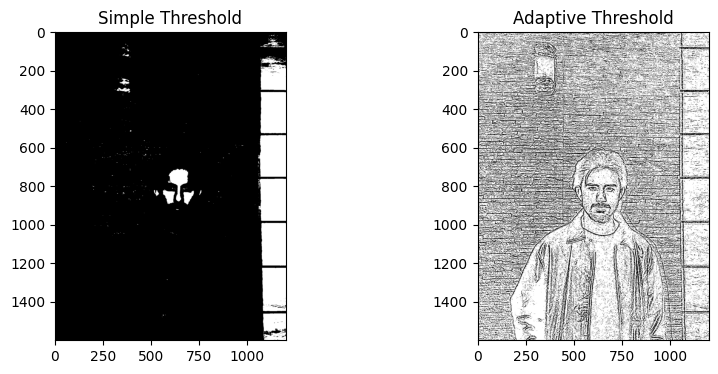

In [13]:
if img is not None:

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Simple Threshold
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Adaptive Threshold
    adaptive = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(thresh, cmap='gray')
    plt.title("Simple Threshold")

    plt.subplot(1,2,2)
    plt.imshow(adaptive, cmap='gray')
    plt.title("Adaptive Threshold")

    plt.show()


## 6. Edge Detection

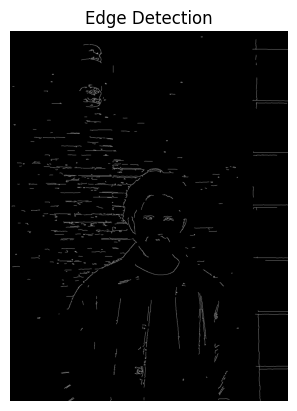

In [14]:
if img is not None:

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    plt.imshow(edges, cmap='gray')
    plt.title("Edge Detection")
    plt.axis('off')
    plt.show()


## 7. Contours & Shape Detection

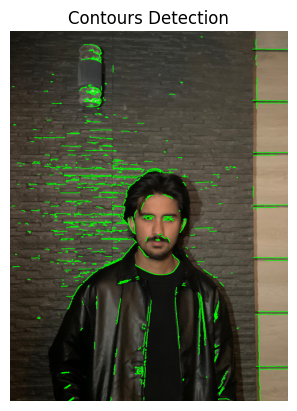

In [15]:
if img is not None:

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = img.copy()

    cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title("Contours Detection")
    plt.axis('off')
    plt.show()


## 8. Face Detection

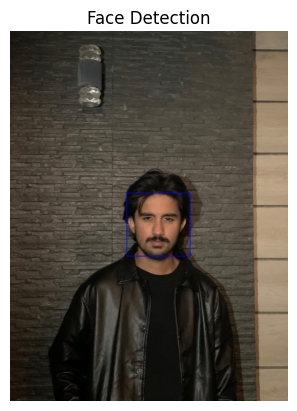

In [18]:
# Face Detection using Haar Cascade

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

if img is not None:

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.5,
        minNeighbors=6
    )

    face_img = img.copy()

    for (x, y, w, h) in faces:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    plt.title("Face Detection")
    plt.axis('off')
    plt.show()
